**Analyse complète de la série temporelle "nombre d'offres créées par mois"**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine

# Connexion à SQL

server = '172.16.11.33'
database = 'LogiProDev'
username = 'quentin'
password = 'Barbidur1;SQL'
driver = 'ODBC+Driver+17+for+SQL+Server'

connection_string = f"mssql+pyodbc://{username}:{password}@{server}/{database}?driver={driver}"

engine = create_engine(connection_string)

# Requête pour importer les colonnes potentiellement utiles

requete = """select offre_id,
    adresse_id,
	offre_type_id,
	groupe_id,
	agence_id,
	nature_offre_id,
	off_date_creation,
	off_surface_totale,
	off_surface_minimum,
	off_date_disponibilite_texte,
	off_directe,
	off_independant,
	off_type_bureau,
	off_type_commerce,
	off_type_activite,
	off_type_terrain,
	fiscal_location_id,
	fiscal_vente_id,
	revision_annuelle_id,
	paiement_loyer_id
	from dbo.t_offre
	where off_surface_totale > 0 and groupe_id != 38
	order by off_date_creation desc"""
	
df = pd.read_sql(requete, engine)


Création et visualisation de la série temporelle représentant le nombre d'offres publiées par mois

C:\Users\quent\AppData\Local\Temp\ipykernel_26120\3857778629.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_range = pd.date_range(


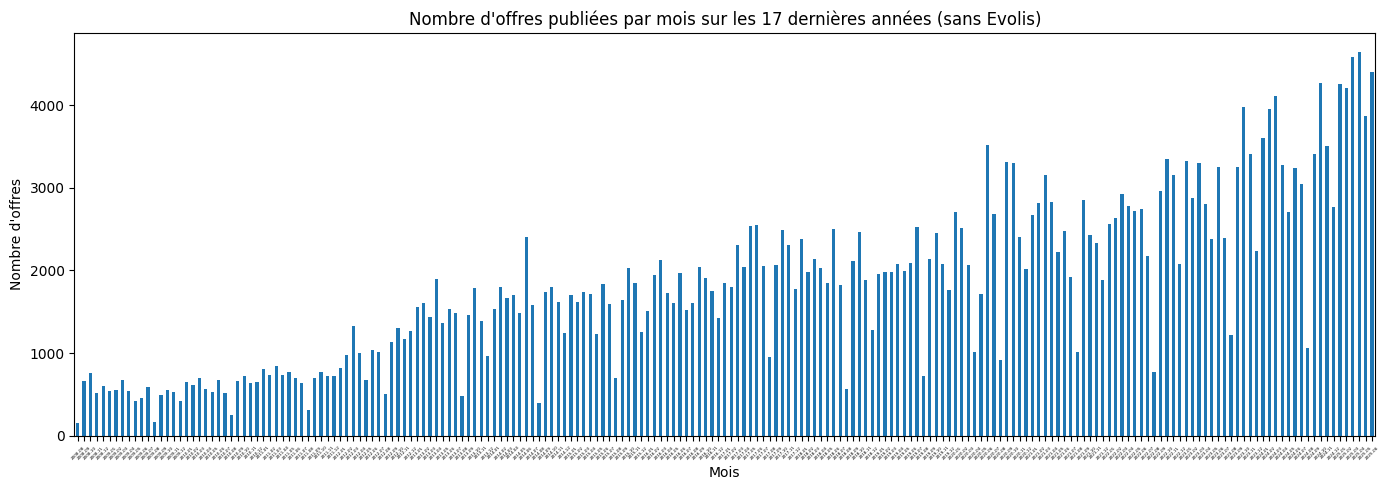

In [5]:
# On agrège par mois dès le départ pour éviter d'avoir trop de valeur, un modèle par jour serait trop complexe à analyser.

import pandas as pd
import matplotlib.pyplot as plt

# Convertir
df['off_date_creation'] = pd.to_datetime(df['off_date_creation'])

# Filtrer les données (3 ans pour avoir assez de données au départ)
ajd = pd.Timestamp.today()
seventeen_years_ago = ajd - pd.DateOffset(years=17)
df_recent = df[df['off_date_creation'] >= seventeen_years_ago].copy()

# Calculer le mois (fin de mois ici)
df_recent['mois'] = df_recent['off_date_creation'].dt.to_period('M').dt.to_timestamp() + pd.offsets.MonthEnd(0)

# Regrouper
df_grouped = df_recent.groupby('mois').size().reset_index(name='nb_offres')

# Plage complète des fins de mois
full_range = pd.date_range(
    start=df_grouped['mois'].min(),
    end=df_grouped['mois'].max(),
    freq='M'
)
df_full = pd.DataFrame({'mois': full_range})

# Fusion
df_complete = pd.merge(df_full, df_grouped, on='mois', how='left')
df_complete['nb_offres'] = df_complete['nb_offres'].fillna(0).astype(int)
# Supprimer le mois de juillet 2025 car trop peu d'offres publiées, outlier évident.
# df_complete = df_complete[df_complete['mois'] != pd.Timestamp('2025-07-31')]
df_complete = df_complete[df_complete['mois'] != df_complete['mois'].max()]

# Affichage
ax = df_complete.plot(
    x='mois',
    y='nb_offres',
    kind='bar',
    figsize=(14, 5),
    legend=False,
    title=f'Nombre d\'offres publiées par mois sur les 17 dernières années (sans Evolis)'
)
ax.set_xticks(range(len(df_complete)))
ax.set_xticklabels(df_complete['mois'].dt.strftime('%Y-%m'), rotation=45, fontsize=3)
plt.xlabel("Mois")
plt.ylabel("Nombre d'offres")
plt.tight_layout()
plt.show()

Quelques observations : la série temporelle présente une tendance croissante claire et une saisonalité évidente de 12 mois, avec une baisse de l'activité quasi systématique au mois d'août. On observe également que la variance croît au cours du temps. 

Afin de mener une analyse rigoureuse, il faut transformer la série afin de la rendre stationnaire (oscillante autour d'une moyenne, mathématiquement, il faut que sa moyenne empirique converge presque sûrement vers son espérance). Il faut aussi impérativement contrôler l'évolution de la variance. Pour cela, une autre transformation s'impose : la transformation Box-Cox. Il s'agit d'une transformation généralisant la transformation logarithmique. 

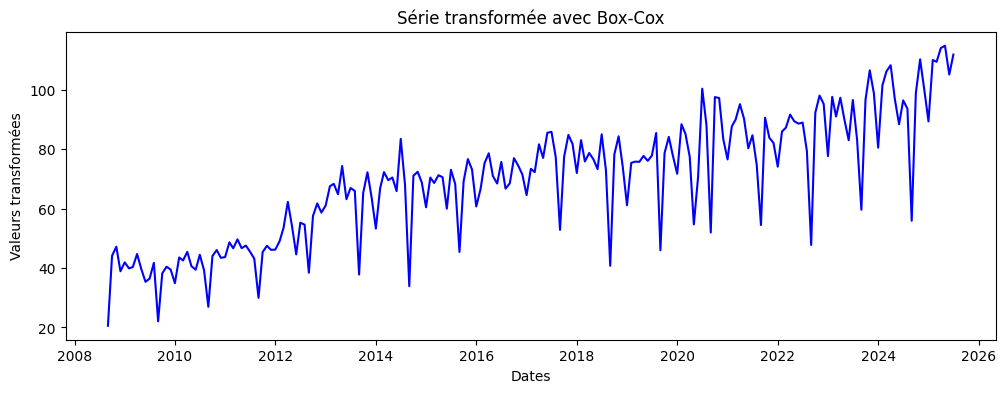

In [6]:
from scipy import stats

# Appliquer Box-Cox sans écraser la colonne originale
nb_offres_boxcox, lambda_opt = stats.boxcox(df_complete['nb_offres'] + 1e-6)  
# +1e-6 pour éviter zéro si jamais

# Créer un nouveau DataFrame avec la colonne mois et la série transformée
df_boxcox = df_complete[['mois']].copy()
df_boxcox['nb_offres_boxcox'] = nb_offres_boxcox

# Tracer la série transformée
plt.figure(figsize=(12,4))
plt.plot(df_boxcox['mois'], df_boxcox['nb_offres_boxcox'], color='blue')
plt.title('Série transformée avec Box-Cox')
plt.xlabel('Dates')
plt.ylabel('Valeurs transformées')
plt.show()


In [7]:
print(lambda_opt)

0.4761312367217168


La série ayant subi la transformation Box-Cox optimale se comporte déjà d'une manière plus régulière : mis à part les variations saisonnières du mois d'août, l'amplitude des oscillations a été contrôlée au cours du temps. Il reste toujours une petite différence notable à l'oeil toutefois.

La série à ce stade n'est pas encore stationnaire, elle présente encore sa tendance croissante. La sélection automatique du meilleur modèle ARIMA choisira dans le même temps le meilleur "ordre de différenciation" pour rendre la série stationnaire. 

On va fit automatiquement un modèle ARIMA (=auturegressive integrated moving average process)

Il s'agit d'étudier non pas la série en elle-même, mais la série différenciée ((X_n - X_{n-1}) au lieu de (X_n)). Appliquer cette opération est utile pour l'analyse car les théorèmes et tests statistiques ne sont valides pour la plupart qu'en présence qu'une série dite "stationnaire" (une série stationnaire est une série qui oscille aléatoirement autour d'une certaine valeur). Ici, on a besoin de différenciation car la série brut présente une tendance à la hausse : elle n'est pas stationnaire. D'où l'utilisation du "Integrated". AR signifie autoregressive : la valeur suivante de la série temporelle est fonction des précédentes. MA signifie moving average : les évolutions aléatoires de la série proviennent d'un "bruit blanc", c'est à dire d'une séquence de valeurs aléatoires centrées en 0 et oscillant normalement (au sens probabiliste) autour de cette valeur.

In [9]:
import pmdarima

In [11]:
model_arima = pmdarima.auto_arima(
    df_boxcox['nb_offres_boxcox'], 
    seasonal=True, 
    m=12, # a priori, comme la série est mensuelle, on recherche de la saisonnalité  sur 12 mois.
    error_action='ignore', 
    suppress_warnings=True,
    stepwise=True
)

c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes p

On ne va pas détecter les outliers ici car aucun outlier ne ressort à la visualisation de la série. Soit on ne décterait aucun outlier si on utilise une sensibilité faible, soit on détecterait tous les mois d'août comme outliers alors que leur valeur basse est plutôt imputable de manière assez évidente à un effet de saisonnalité qui sera automatiquement modélisé plus tard par le modèle SARIMA.

c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


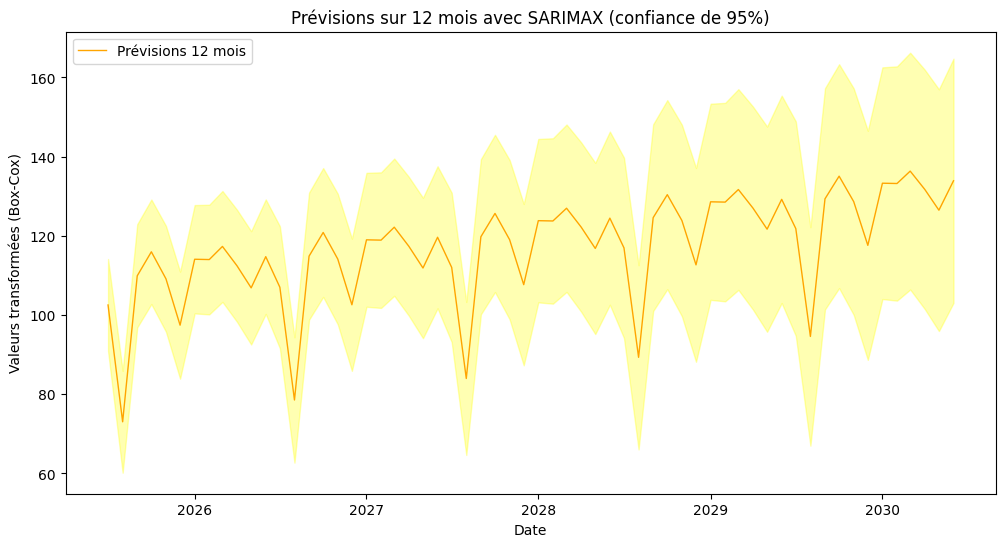

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assurer que l'index est datetime
if not isinstance(df_boxcox.index, pd.DatetimeIndex):
    df_boxcox['mois'] = pd.to_datetime(df_boxcox['mois'])
    df_boxcox.set_index('mois', inplace=True)

n_periods = 60

# Récupérer prévisions et IC
forecast, conf_int = model_arima.predict(n_periods=n_periods, return_conf_int=True)

# Créer l'index des dates pour les prévisions (début du mois suivant)
last_date = df_boxcox.index[-1]
forecast_index = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=n_periods, freq='MS')

# Utiliser uniquement les valeurs (ignore l'ancien index numérique)
forecast_series = pd.Series(forecast.values, index=forecast_index)

plt.figure(figsize=(12,6))
plt.plot(forecast_series.index, forecast_series.values, label='Prévisions 12 mois', color='orange', linewidth=1)
plt.fill_between(forecast_index, conf_int[:, 0], conf_int[:, 1], color='yellow', alpha=0.3)
plt.title('Prévisions sur 12 mois avec SARIMAX (confiance de 95%)')
plt.xlabel('Date')
plt.ylabel('Valeurs transformées (Box-Cox)')
plt.legend()
plt.show()

ATTENTION !! LES PREDICTIONS SE FONT SUR LA SERIE AYANT SUBI LA TRANSFORMATION BOX-COX. IL FAUT EFFCTUER LA TRANSFORMATIONS INVERSE POUR OBTENIR LES VALEURS PREDITES POUR LA SERIE BRUTE : La transformation de Box-Cox est définie par :

\[
f_\lambda(y) = 
\begin{cases} 
\frac{y^\lambda - 1}{\lambda}, & \text{si } \lambda \neq 0 \\
\ln(y), & \text{si } \lambda = 0
\end{cases}
\]

où \(y > 0\) et \(\lambda\) est le paramètre de transformation.


                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  203
Model:             SARIMAX(0, 1, 2)x(1, 0, [1], 12)   Log Likelihood                -657.526
Date:                              Thu, 07 Aug 2025   AIC                           1325.053
Time:                                      14:53:08   BIC                           1341.594
Sample:                                           0   HQIC                          1331.745
                                              - 203                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5248      0.071     -7.389      0.000      -0.664      -0.386
ma.L2         -0.29

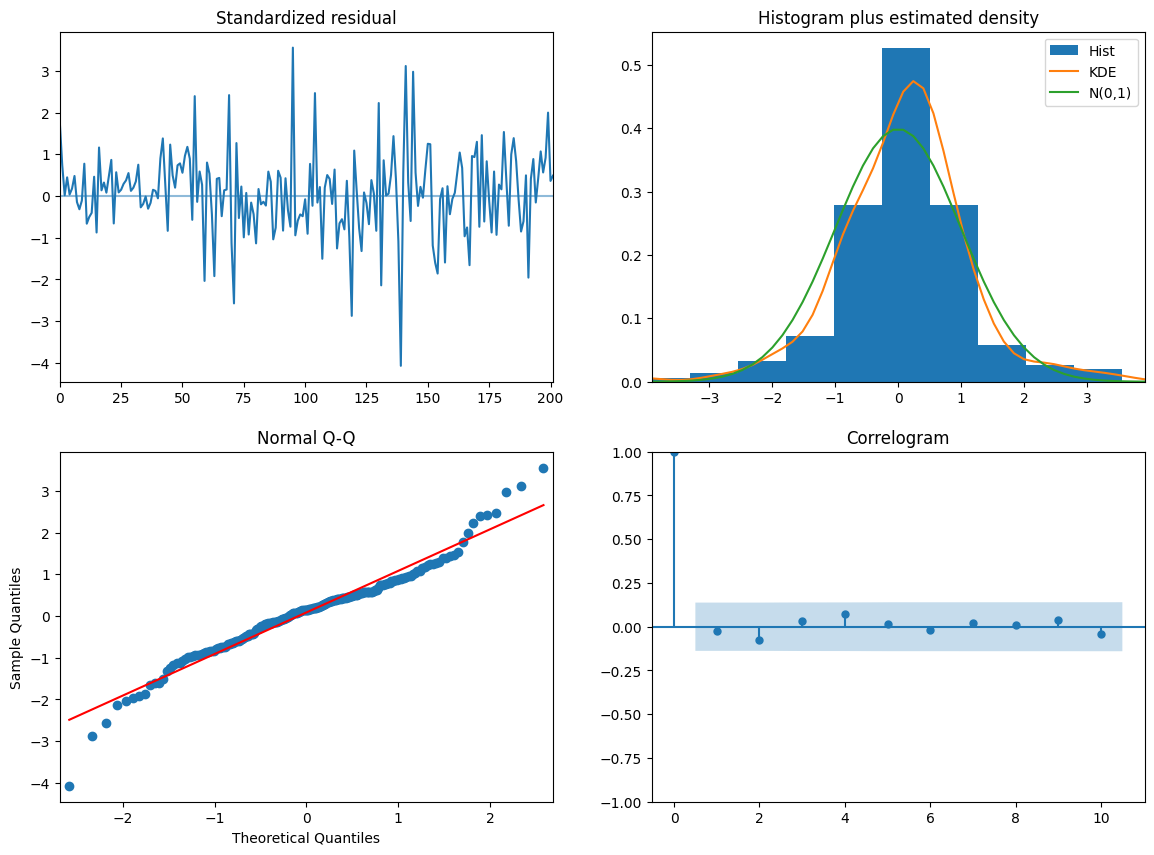

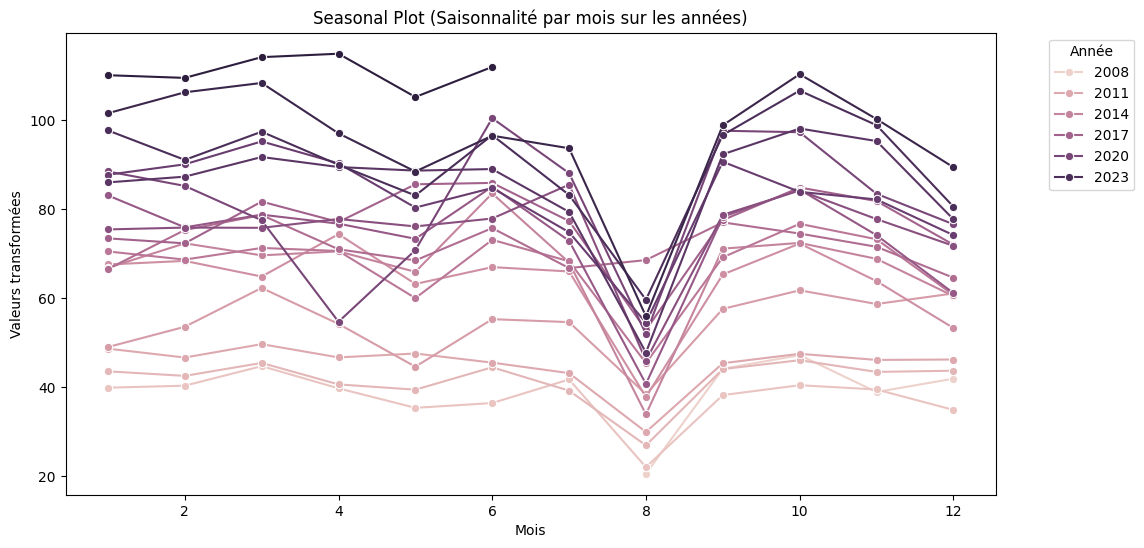

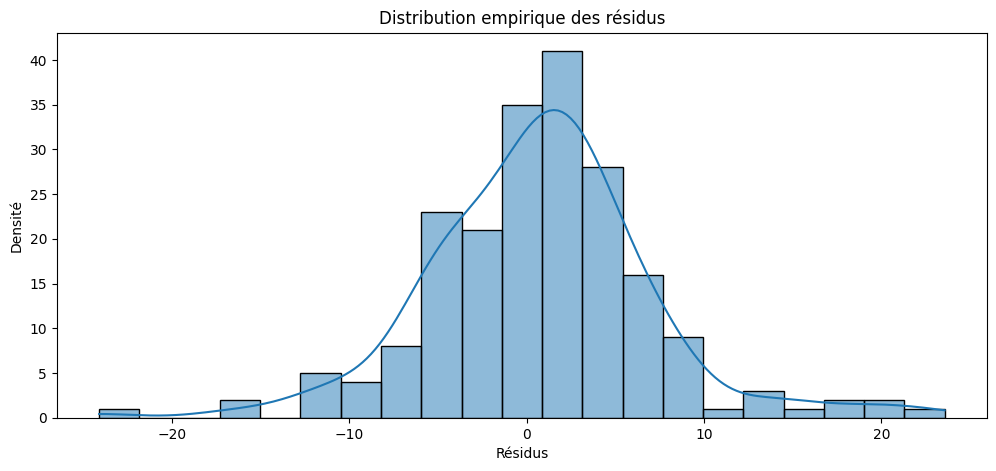

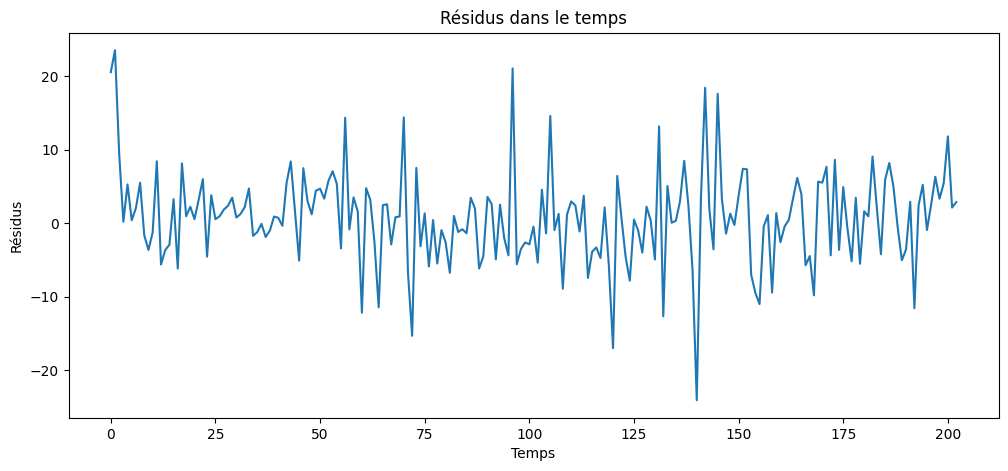

In [13]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# 1. Résumé textuel du modèle
print(model_arima.summary())

# 2. Graphiques diagnostics classiques (résidus, qq-plot, autocorrélation)
model_arima.plot_diagnostics(figsize=(14, 10))
plt.show()

# 3. Graphique de la saisonnalité (seasonal plot)
# On peut utiliser la série historique pour cela, avec seaborn

df_plot = df_boxcox.copy()
df_plot = df_plot.reset_index()
df_plot['month'] = df_plot['mois'].dt.month
df_plot['year'] = df_plot['mois'].dt.year

plt.figure(figsize=(12,6))
sns.lineplot(data=df_plot, x='month', y='nb_offres_boxcox', hue='year', marker='o')
plt.title('Seasonal Plot (Saisonnalité par mois sur les années)')
plt.xlabel('Mois')
plt.ylabel('Valeurs transformées')
plt.legend(title='Année', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 4. Distribution empirique des résidus

residuals = pd.Series(model_arima.resid())

plt.figure(figsize=(12,5))
sns.histplot(residuals, kde=True)
plt.title('Distribution empirique des résidus')
plt.xlabel('Résidus')
plt.ylabel('Densité')
plt.show()

# 5. Trace des résidus vs temps pour vérifier l’homoscédasticité

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title('Résidus dans le temps')
plt.xlabel('Temps')
plt.ylabel('Résidus')
plt.show()


Interprétons ces graphiques : Les résidus sont la différence entre les valeurs prédites et les valeurs réelles. Si le modèle choisi est bon pour prédire la série, alors ces résidus doivent être normalement distribués, homoscédastiques, centrés et décorrélés. 

Qu'est-ce que cela signifie ? 

Les résidus : ce sont les différences entre les valeurs réelles de la série et les valeurs qu'aurait prédit le modèle en ne connaissant que les valeurs passées. Il s'agit de ce que n'arrive pas à prévoir le modèle stochastique. Si le modèle est bien spécifié, ces erreurs doivent être les plus imprévisibles possibles : elles doivent osciller normalement sans s'influencer les unes les autres autour de la moyenne.

Normalement distribués : la distribution empirique des résidus doit se rapprocher le plus possible d'une densité de loi normale. C'est le cas ici, à regarder l'histogramme accompagné de la densité estimée (graphique n°2), on a une proximité relative avec la densité normale la plus proche, ce qu'on peut également lire sur le graphique n°6 sur la distribution empirique des résidus.

Homoscédasticité : l'homoscédasticité désigne la stabilité de la variance de la série au cours du temps. Si la variance est faible à un certain moment (oscillations de faible amplitude) et plus forte à un autre (oscillations de plus forte amplitude) alors soit le modèle est mal spécifié soit la série n'a pas subi la transformation adéquate avant de la modéliser avec un ARIMA. On peut lire sur les graphiques n°1 et n°7 que les résidus ne semblent pas avoir de volatilité variable dans le temps.

Centrés : les résidus (rappelons : ce que le modèle n'est pas parvenu à bien prévoir) doivent être centrés autour des vraies valeurs, celles qui auraient dû être prédites pour que le modèle ait raison. De manière assez logique, il vaut mieux qu'ils soient centrés autour de 0. On peut toujours observer cela sur les graphiques n°1 et n°7. 

Autocorrélations : le graphique n°4, un autocorrélogramme, présente pour chaque distance temporelle la valeur de la covariance qui a été estimée par la machine entre deux valeurs de la série à cette distance. Si le modèle réussit à capturer la dépendance entre les différentes valeurs de la série alors les résidus ne doivent pas présenter de corrélation entre eux, sinon le modèle a manqué quelque chose. Les autocorrélations doivent donc toutes se trouver à l'intérieur de l'intervalle de confiance à 95% dessiné en bleu pour toute distance supérieure ou égale à 1. C'est le cas ici. 

Enfin, le season plot (graphique n°5) permet de mieux visualiser les creux systématiques au mois d'août. 

Bonus : interprétation du Q-Q plot (graphique n°3). Il s'agit d'évaluer la distance entre les quantiles de la loi des résidus estimée par maximum de vraisemblance (méthode statistique d'estimation particulièrement robuste) par la machine et ceux de la loi normale la plus proche. La droite représente ceux de la loi normale et les points ceux de la distribution empirique des résidus. Plus les points sont proches de la droite, plus c'est bon signe. Ici, les points sont très proches de la droite, on peut donc considérer que la loi estimée est suffisamment proche de la loi normale pour que l'hypothèse d'égalité entre ces deux lois, et donc de normalité des résidus, soit crédible. 

La ligne model donne les parametres du modele (degrés des polynômes autorégressif et moving average), ainsi que l'ordre de saisonnalité, on l'a vu ci-dessus

No. Observations donne le nombre de valeurs que contient la série temporelle. Ici, 204.
Plus la logvraisemblance est basse, mieux c'est. Il s'agit d'une mesure de la vraisemblance du modèle. Une valeur en-dessous de -1000 est bon signe

Les critères d'information AIC BIC et HQIC doivent être les plus bas possibles. Ici, on nous montre la valeur pour le modèle qui avait la meilleure rmse parmi les modèles qui proposaient des faibles valeurs pour ces critères

Pour le deuxième tableau, coeff donne le coefficient estimé, std error son écart type, z donne la valeurde la t-stat du test de nullité du coefficient, P>|z| donne la p-valeur du test de nullité du coefficient. Une faible p-value signifie qu'on rejette avec confiance cette hypothèse de nullité, et donc signifie qu'on est confiant pour dire que le coefficient est non nul, c'est à dire que la valeur de la période passée joue bien un role dans la prédiction. Les p-values doivent être plus basses que 5%, sinon le résultat du test est dit non sgnificatif.

La matrice de covariance est utilisée pour calculer certaines de ces valeurs, elle n'est pas utile pour l'interprétation des résultats du modèle.

Interprétation des paramètres du modèle SARIMAX sélectionné : SARIMAX(0, 1, 2)x(1, 0, [1], 12). 

In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Faire les prédictions in-sample (sur les mêmes points que les données d'entraînement)
y_true = df_boxcox['nb_offres_boxcox']

# model_arima.predict_in_sample() donne les valeurs prédites sur la série d'origine
y_pred = model_arima.predict_in_sample()

# Calculer la RMSE
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"RMSE in-sample: {rmse:.4f}")

RMSE in-sample: 6.3815


On calcule la racine de l'erreur quadratique moyenne qu'a commis le modèle sur l'échantillon d'entraînement. Plus elle est faible, plus le modèle parvient à bien prévoir de nouvelles valeurs. 

Sélection du meilleur modèle stochastique entre SARIMA et Prophet  **CODE NE FONCTIONNERA PLUS A PARTIR D'ICI**

In [ ]:
from pmdarima import auto_arima
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# 1. Détection des outliers (valeurs aberrantes) sur df_complete
# On ne va pas le faire ici car aucun outlier ne ressort à la visualisation de la série.
# Soit on ne décterait aucun outlier si on utilise une sensibilité faible, soit on détecterait tous les mois d'août comme outliers alors que leur
# valeur basse est plutôt imputable de manière assez évidente à un effet de saisonnalité qui sera automatiquement modélisé plus tard par le modèle
# SARIMA.

# 2. Fit automatique ARIMA (=auturegressive integrated moving average process)
# Il s'agit d'étudier non pas la série en elle-même, mais la série différenciée ((X_n - X_{n-1}) au lieu de (X_n)). Appliquer cette opération
# est utile pour l'analyse car les théorèmes et tests statistiques ne sont valides pour la plupart qu'en présence qu'une série dite "stationnaire"
# (une série stationnaire est une série qui oscille aléatoirement autour d'une certaine valeur)
# Ici, on a besoin de différenciation car la série brut présente une tendance à la hausse : elle n'est pas stationnaire. D'où l'utilisation du 
# "Integrated"
# AR signifie autoregressive : la valeur suivante de la série temporelle est fonction des précédentes
# MA signifie moving average : les évolutions aléatoires de la série proviennent d'un "bruit blanc", c'est à dire d'une séquence de valeurs
# aléatoires centrées en 0 et oscillant normalement (au sens probabiliste) autour de cette valeur.
model_arima = auto_arima(
    df_complete['nb_offres'], 
    seasonal=True, 
    m=12, # a priori, comme la série est mensuelle, on recherche de la saisonnalité  sur 12 mois.
    error_action='ignore', 
    suppress_warnings=True,
    stepwise=True
)

# VARIABLES IMPORTANTES : model_arima EST LE MEILLEUR MODELE ARIMA 


c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes p

In [ ]:
# 3. Fit Prophet
# Il s'agit d'un modèle stochastique suivant le même principe qu'ARIMA, mais intégrant de la saisonnalité journalière et hebdomadaire. 
# A priori, comme les données considérées ici sont mensuelles, prophet devrait moins bien fonctioner que ARIMA.
from prophet.diagnostics import cross_validation, performance_metrics
from prophet import Prophet


df_prophet = df_complete[['mois', 'nb_offres']].rename(columns={'mois': 'ds', 'nb_offres': 'y'}) # Prophet demande ces noms de colonne pour fonctionner

rmse_prophet=[] # on va y stocker les différentes rmse obtenues sur nos valeurs tests
for prior_scale_param in [0.01,0.02,0.03,0.04,0.05]:
    model = Prophet(seasonality_mode='multiplicative',
    weekly_seasonality=False,
    daily_seasonality=False,
    yearly_seasonality=True,
    changepoint_prior_scale=prior_scale_param
    )
    model.fit(df_prophet)
    df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')
    rmse_provisoire = performance_metrics(df_cv)['rmse'].mean()
    rmse_prophet.append(rmse_provisoire)
meilleur_indice = rmse_prophet.index(min(rmse_prophet))
prior_scale_param = [0.01,0.02,0.03,0.04,0.05][meilleur_indice]

model_prophet = Prophet(
    seasonality_mode='multiplicative',
    weekly_seasonality=False,
    daily_seasonality=False,
    yearly_seasonality=True,
    changepoint_prior_scale = prior_scale_param # Ajuste l'adaptabilité de la tendance aux sauts brutaux. Avec une valeur faible comme celle-ci, on empêche
    # la tendance de faire des plongeons au moment des creux en août. Avec une valeur élevée, les creux auraient fait partie de la tendance alors
    # que ce sont plutôt des effets que l'ont cherche à capturer à travers les paramètres de saisonnalité.
)
model_prophet.fit(df_prophet)

print(prior_scale_param)

# VARIABLES IMPORTANTES : model_prophet EST LE MEILLEUR MODELE PROPHET SELECTIONNE AUTOMATIQUEMENT

10:01:07 - cmdstanpy - INFO - Chain [1] start processing
10:01:08 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/29 [00:00<?, ?it/s]

10:01:08 - cmdstanpy - INFO - Chain [1] start processing
10:01:08 - cmdstanpy - INFO - Chain [1] done processing
10:01:08 - cmdstanpy - INFO - Chain [1] start processing
10:01:08 - cmdstanpy - INFO - Chain [1] done processing
10:01:08 - cmdstanpy - INFO - Chain [1] start processing
10:01:08 - cmdstanpy - INFO - Chain [1] done processing
10:01:09 - cmdstanpy - INFO - Chain [1] start processing
10:01:09 - cmdstanpy - INFO - Chain [1] done processing
10:01:09 - cmdstanpy - INFO - Chain [1] start processing
10:01:09 - cmdstanpy - INFO - Chain [1] done processing
10:01:09 - cmdstanpy - INFO - Chain [1] start processing
10:01:09 - cmdstanpy - INFO - Chain [1] done processing
10:01:10 - cmdstanpy - INFO - Chain [1] start processing
10:01:10 - cmdstanpy - INFO - Chain [1] done processing
10:01:10 - cmdstanpy - INFO - Chain [1] start processing
10:01:10 - cmdstanpy - INFO - Chain [1] done processing
10:01:10 - cmdstanpy - INFO - Chain [1] start processing
10:01:11 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/29 [00:00<?, ?it/s]

10:01:16 - cmdstanpy - INFO - Chain [1] start processing
10:01:16 - cmdstanpy - INFO - Chain [1] done processing
10:01:16 - cmdstanpy - INFO - Chain [1] start processing
10:01:17 - cmdstanpy - INFO - Chain [1] done processing
10:01:17 - cmdstanpy - INFO - Chain [1] start processing
10:01:17 - cmdstanpy - INFO - Chain [1] done processing
10:01:17 - cmdstanpy - INFO - Chain [1] start processing
10:01:17 - cmdstanpy - INFO - Chain [1] done processing
10:01:17 - cmdstanpy - INFO - Chain [1] start processing
10:01:17 - cmdstanpy - INFO - Chain [1] done processing
10:01:18 - cmdstanpy - INFO - Chain [1] start processing
10:01:18 - cmdstanpy - INFO - Chain [1] done processing
10:01:18 - cmdstanpy - INFO - Chain [1] start processing
10:01:18 - cmdstanpy - INFO - Chain [1] done processing
10:01:18 - cmdstanpy - INFO - Chain [1] start processing
10:01:19 - cmdstanpy - INFO - Chain [1] done processing
10:01:19 - cmdstanpy - INFO - Chain [1] start processing
10:01:19 - cmdstanpy - INFO - Chain [1]

...

  0%|          | 0/29 [00:00<?, ?it/s]

10:01:32 - cmdstanpy - INFO - Chain [1] start processing
10:01:32 - cmdstanpy - INFO - Chain [1] done processing
10:01:32 - cmdstanpy - INFO - Chain [1] start processing
10:01:32 - cmdstanpy - INFO - Chain [1] done processing
10:01:32 - cmdstanpy - INFO - Chain [1] start processing
10:01:32 - cmdstanpy - INFO - Chain [1] done processing
10:01:32 - cmdstanpy - INFO - Chain [1] start processing
10:01:33 - cmdstanpy - INFO - Chain [1] done processing
10:01:33 - cmdstanpy - INFO - Chain [1] start processing
10:01:33 - cmdstanpy - INFO - Chain [1] done processing
10:01:33 - cmdstanpy - INFO - Chain [1] start processing
10:01:33 - cmdstanpy - INFO - Chain [1] done processing
10:01:33 - cmdstanpy - INFO - Chain [1] start processing
10:01:34 - cmdstanpy - INFO - Chain [1] done processing
10:01:34 - cmdstanpy - INFO - Chain [1] start processing
10:01:34 - cmdstanpy - INFO - Chain [1] done processing
10:01:34 - cmdstanpy - INFO - Chain [1] start processing
10:01:34 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/29 [00:00<?, ?it/s]

10:01:39 - cmdstanpy - INFO - Chain [1] start processing
10:01:39 - cmdstanpy - INFO - Chain [1] done processing
10:01:40 - cmdstanpy - INFO - Chain [1] start processing
10:01:40 - cmdstanpy - INFO - Chain [1] done processing
10:01:40 - cmdstanpy - INFO - Chain [1] start processing
10:01:40 - cmdstanpy - INFO - Chain [1] done processing
10:01:40 - cmdstanpy - INFO - Chain [1] start processing
10:01:40 - cmdstanpy - INFO - Chain [1] done processing
10:01:41 - cmdstanpy - INFO - Chain [1] start processing
10:01:41 - cmdstanpy - INFO - Chain [1] done processing
10:01:41 - cmdstanpy - INFO - Chain [1] start processing
10:01:41 - cmdstanpy - INFO - Chain [1] done processing
10:01:41 - cmdstanpy - INFO - Chain [1] start processing
10:01:42 - cmdstanpy - INFO - Chain [1] done processing
10:01:42 - cmdstanpy - INFO - Chain [1] start processing
10:01:42 - cmdstanpy - INFO - Chain [1] done processing
10:01:42 - cmdstanpy - INFO - Chain [1] start processing
10:01:43 - cmdstanpy - INFO - Chain [1]

0.02


In [ ]:
# 4. Comparaison de performances (sur les 12 derniers mois) : on va utiliser toutes les données sauf les 12 dernières pour essayer de prédire 
# les 12 dernières données, que l'on connaît déjà, et évaluer quel modèle parvient le mieux à les prévoir.
horizon = 12
y_true = df_complete['nb_offres'].iloc[-horizon:] # les vraies dernières valeurs de la série, qu'on va comparer aux valeurs prédites

# Prédiction ARIMA :
y_pred_arima = model_arima.predict(n_periods=horizon)
rmse_arima = np.sqrt(mean_squared_error(y_true, y_pred_arima)) # On calcule l'erreur. Importante pour comparer la performance des modèles

# Prédiction Prophet :
future = model_prophet.make_future_dataframe(periods=horizon, freq='M')
forecast = model_prophet.predict(future)
y_pred_prophet = forecast.tail(horizon)['yhat']
rmse_prophet = np.sqrt(mean_squared_error(y_true, y_pred_prophet)) # et on calcule l'erreur pour le modèle Prophet

c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


Les résidus ARIMA ne vérifient pas toutes les conditions. Possibles anomalies non corrigées

 Paramètres du meilleur modèle ARIMA :
Ordre non saisonnier (p,d,q)     : (3, 1, 1)
Ordre saisonnier (P,D,Q,m)       : (1, 0, 1, 12)

 Résumé complet du modèle ARIMA :
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  204
Model:             SARIMAX(3, 1, 1)x(1, 0, 1, 12)   Log Likelihood               -1466.116
Date:                            Fri, 25 Jul 2025   AIC                           2946.232
Time:                                    10:01:48   BIC                           2969.425
Sample:                                         0   HQIC                          2955.615
                                            - 204                                         
Covariance Type:                              opg                                         
           

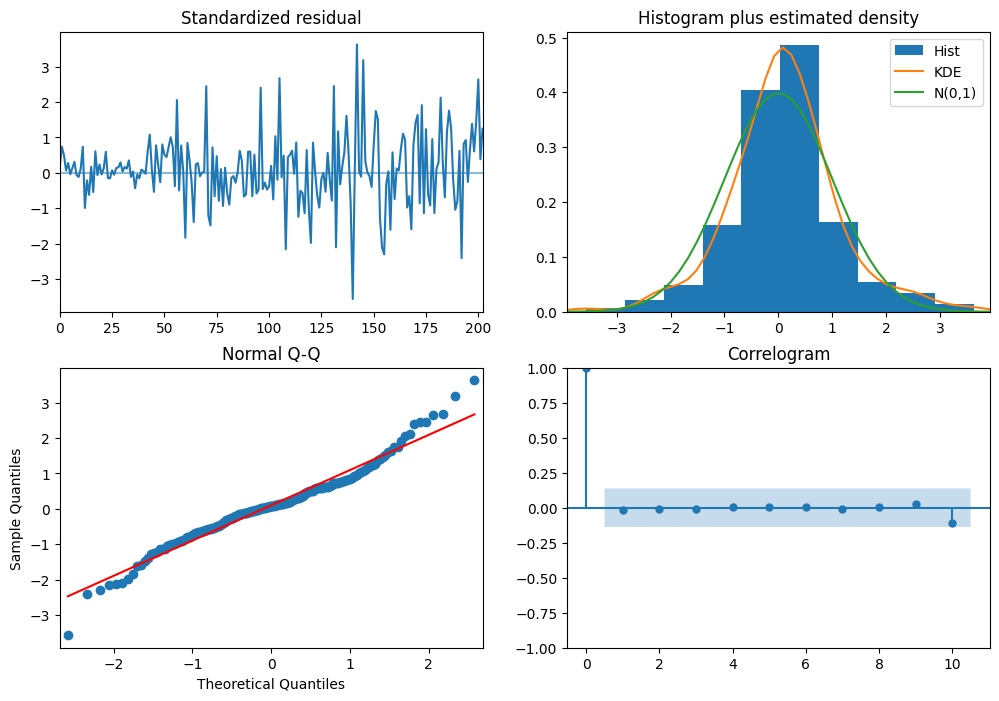

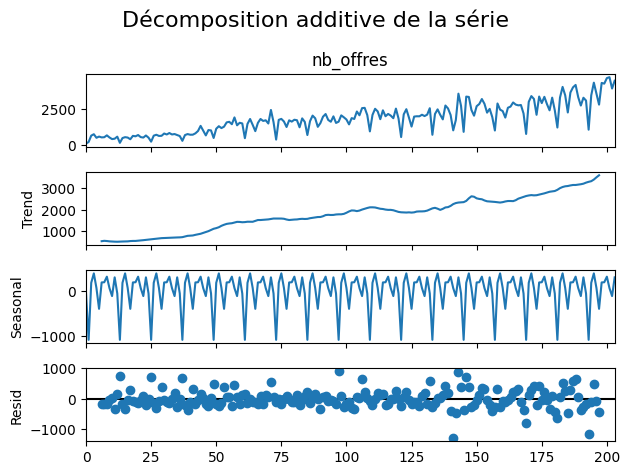

In [ ]:
# 5. Afficher les paramètres du meilleur modèle ARIMA
# Les résidus sont la différence entre les valeurs prédites et les valeurs réelles. 
# Si le modèle choisi est bon pour prédire la série, alors ces résidus doivent être normalement distribués, hétéroscédastiques, centrés
# et mutuellement indépendants.
# On affiche un message d'alerte s'il s'avère que les résidus ne vérifient pas ces trois conditions.

# Même si le meilleur modèle n'est pas forcément le ARIMA, visualisons les résultats, ils peuvent être instructifs pour la suite :

resid = model_arima.resid()
mean_resid = resid.mean() # Il faut qu'elle soit proche de 0
std_resid = resid.std()
seuil_std = 3 * np.std(df_complete['nb_offres']) # on compare à la déviation standard = écart type de la vraie série pour vérifier la condition
# d'hétéroscédasticité (c'est à dire variance constante dans le temps)

if abs(mean_resid) > 0.2 or std_resid > seuil_std:
    print("Les résidus ARIMA ne vérifient pas toutes les conditions. Possibles anomalies non corrigées")
else:
    print("Les résidus ARIMA sont bien un bruit blanc")

caracteristiques=model_arima.summary()
param_non_saison=model_arima.order 
param_saison=model_arima.seasonal_order 
print("\n Paramètres du meilleur modèle ARIMA :")
print(f"Ordre non saisonnier (p,d,q)     : {param_non_saison}") # par exemple (2,1,1) signifie que chaque valeur dépend des deux précédentes, 
                                                                # qu'on a dû différencier une fois la série pour la rendre stationnaire,
                                                                # et que chaque valeur dépend du bruit ajouté à l'étape précédente, 
print(f"Ordre saisonnier (P,D,Q,m)       : {param_saison}") # le m donne la période de saisonnalité
print("\n Résumé complet du modèle ARIMA :")
print(caracteristiques)

# Interprétation de la sortie : la ligne model donne les parametres du modele (degrés des polynômes autorégressif et moving average), ainsi que l'ordre de saisonnalité, on l'a vu ci-dessus
# No. Observations donne le nombre de valeurs que contient la série temporelle. Ici, 204.
# Plus la logvraisemblance est basse, mieux c'est. Il s'agit d'une mesure de la vraisemblance du modèle. Une valeur en-dessous de -1000 est bon signe
# Les critères d'information AIC BIC et HQIC doivent être les plus bas possibles. Ici, on nous montre la valeur pour le modèle qui avait la meilleure rmse parmi les modèles qui proposaient des faibles valeurs pour ces critères
# Pour le deuxième tableau, coeff donne le coefficient estimé, std error son écart type, z donne la valeurde la t-stat du test de nullité du coefficient, P>|z| donne la p-valeur du test de nullité du coefficient. Une faible p-value signifie qu'on rejette avec confiance cette hypothèse de nullité, et donc signifie qu'on est confiant pour dire que le coefficient est non nul, c'est à dire que la valeur de la période passée joue bien un role dans la prédiction. Les p-values doivent être plus basses que 5%, sinon le résultat du test est dit non sgnificatif.
# La matrice de covariance est utilisée pour calculer certaines de ces valeurs, elle n'est pas utile pour l'interprétation des résultats du modèle.

model_arima.plot_diagnostics(figsize=(12, 8)) # On remarque que les résidus semble avoir une variance non constante (valeurs contractées au début, plus volatiles à la fin)
# C'est d'ici que provient l'alerte sur les résidus
# L'histogramme de la densité estimée des résidus doit être le plus proche possible d'une densité gaussienne. C'est le cas ici
# L'autocorrélogramme ne doit avoir aucune de ses valeurs qui débordent de l'intervalle de confiance à 95%, sinon cela signifie que les résidus sont corrélés et donc que le modèle a insuffisamment pris en compte l'influence des bruits aux dates précédentes
# Lecture du q-q plot : plus les points sont proches de la droite centrale, plus les quantiles de la distribution estimée des résidus sont proches de ceux d'une loi normale, e comme les quantiles caractérisent la loi, plus la distribution estimée des résidus est proche de celle d'une loi normale
plt.show()

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_complete['nb_offres'], model='additive', period=12)
result.plot()
plt.suptitle("Décomposition additive de la série", fontsize=16)
plt.tight_layout()
plt.show() # La saisonnalité est frappante sur ce graphique

In [ ]:
# 6. Affichage des paramètres du meilleur modèle Prophet
# Les paramètres d'un modèle Prophet sont moins aisément interprétables que ceux d'un modèle ARIMA.
print("\nParamètres de la tendance :")
print(auto_prophet.params) # k : pente de la tendance linéaire, m : ordonnée à l'origine, delta : lieux de variation de pente (25 par défaut),
# trend : valeur estimée de la pente de la tendance en chaque point, sigma : écart-type des résidus observés, beta : coefficients associés à 
# chaque fonction sinusoïdale dans la décomposition de Fourrier (peu utile pour l'interprétation)

print("\nHyperparamètres du modèle Prophet :")
print(f"changepoint_prior_scale = {auto_prophet.changepoint_prior_scale}")
print(f"seasonality_prior_scale = {auto_prophet.seasonality_prior_scale}")

print("\nChangepoints détectés :")
print(model_prophet.changepoints)


Paramètres de la tendance :
OrderedDict([('lp__', array([[444.962]])), ('k', array([[0.643093]])), ('m', array([[0.0694645]])), ('delta', array([[-1.54588e-10, -4.30992e-09, -3.42005e-07, -1.59966e-09,
         3.35496e-09,  2.27724e-09, -2.24878e-09,  4.17664e-09,
         2.59064e-09, -7.58250e-10,  2.08537e-09, -2.59799e-09,
         2.00813e-09, -7.90964e-11,  3.08524e-10,  6.17320e-10,
        -3.08750e-10,  5.34140e-09,  7.27597e-09,  3.23433e-10,
         2.75036e-07,  1.42808e-08,  3.74909e-09,  9.10260e-09,
         2.41883e-08]])), ('sigma_obs', array([[0.0629091]])), ('beta', array([[ 0.105974  ,  0.0535138 , -0.0501382 , -0.0220776 ,  0.00136557,
        -0.105883  ,  0.062714  ,  0.0329623 , -0.0250206 , -0.0147243 ,
         0.00661924, -0.0505669 ,  0.0342969 , -0.014371  , -0.0602057 ,
         0.0117386 ,  0.0177813 , -0.103944  ,  0.0468003 , -0.00021396]])), ('trend', array([[0.0694645, 0.0726914, 0.0758142, 0.0790411, 0.082164 , 0.0853909,
        0.0886178, 0.0915

In [ ]:
# 7. Sélection du meilleur modèle pour la prédiction (celui qui minimise l'erreur quadratique moyenne) :

if rmse_arima < rmse_prophet :
    meilleur_modele = model_arima
else : 
    meilleur_modele = model_prophet

Génération des prédictions

c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\quent\AppData\Local\Temp\ipykernel_8012\3331914457.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_months = pd.date_range(start=df_complete['mois'].iloc[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq='M')


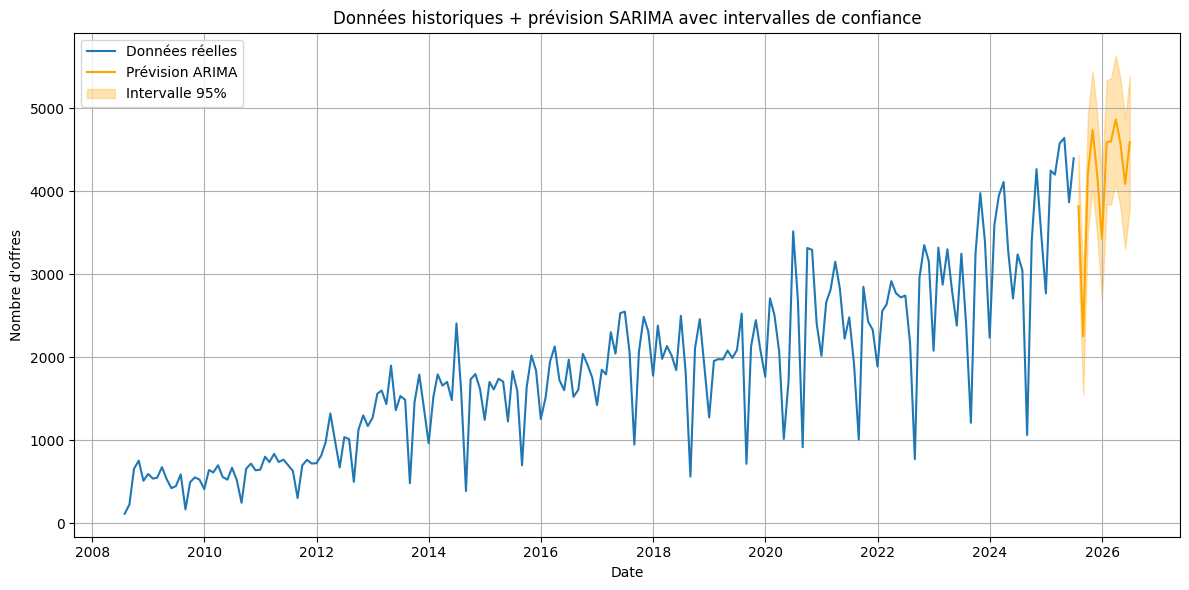

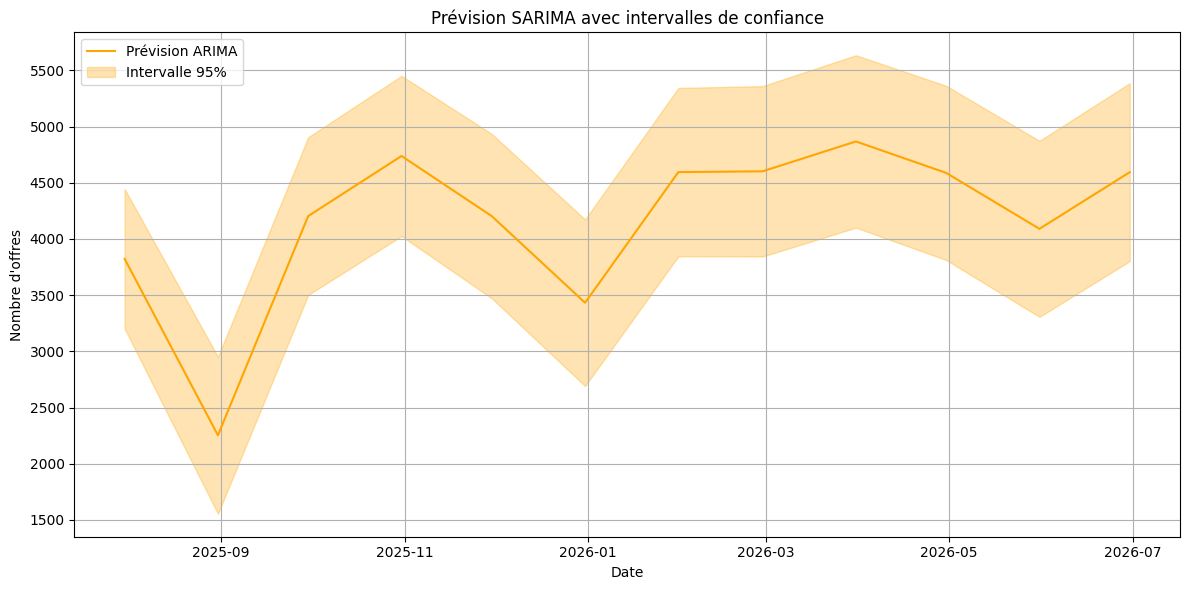

Valeurs prédites pour les prochains mois :
2025-07-31 : 3822.25 (IC95%: [3201.01, 4443.49])
2025-08-31 : 2253.17 (IC95%: [1554.64, 2951.70])
2025-09-30 : 4203.49 (IC95%: [3502.19, 4904.79])
2025-10-31 : 4738.06 (IC95%: [4025.25, 5450.87])
2025-11-30 : 4202.75 (IC95%: [3471.61, 4933.89])
2025-12-31 : 3432.26 (IC95%: [2691.16, 4173.36])
2026-01-31 : 4594.47 (IC95%: [3845.64, 5343.30])
2026-02-28 : 4601.62 (IC95%: [3843.74, 5359.50])
2026-03-31 : 4867.20 (IC95%: [4100.34, 5634.05])
2026-04-30 : 4587.56 (IC95%: [3812.46, 5362.65])
2026-05-31 : 4089.71 (IC95%: [3306.49, 4872.93])
2026-06-30 : 4594.01 (IC95%: [3802.62, 5385.40])


In [ ]:
# 8. Générer les prédictions à horizon de 12 mois pour le meilleur modèle ARIMA
n_total = len(df_complete) + horizon

# Prédictions + intervalle de confiance (par défaut à 95 %)
forecast_arima, conf_int = model_arima.predict(n_periods=horizon, return_conf_int=True)

# Série réelle (entraînement)
plt.figure(figsize=(12, 6))
plt.plot(df_complete['mois'], df_complete['nb_offres'], label='Données réelles')

# Périodes futures (mois futurs)
future_months = pd.date_range(start=df_complete['mois'].iloc[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq='M')

# Prévisions
plt.plot(future_months, forecast_arima, label='Prévision ARIMA', color='orange')

# Intervalle de confiance
plt.fill_between(future_months, conf_int[:, 0], conf_int[:, 1], color='orange', alpha=0.3, label='Intervalle 95%')

plt.title("Données historiques + prévision SARIMA avec intervalles de confiance")
plt.xlabel("Date")
plt.ylabel("Nombre d'offres")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(future_months, forecast_arima, label='Prévision ARIMA', color='orange')
plt.fill_between(future_months, conf_int[:, 0], conf_int[:, 1], color='orange', alpha=0.3, label='Intervalle 95%')
plt.title("Prévision SARIMA avec intervalles de confiance")
plt.xlabel("Date")
plt.ylabel("Nombre d'offres")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Affichage des valeurs prédites
print("Valeurs prédites pour les prochains mois :")
for date, val, low, high in zip(future_months, forecast_arima, conf_int[:, 0], conf_int[:, 1]):
    print(f"{date.date()} : {val:.2f} (IC95%: [{low:.2f}, {high:.2f}])")


c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


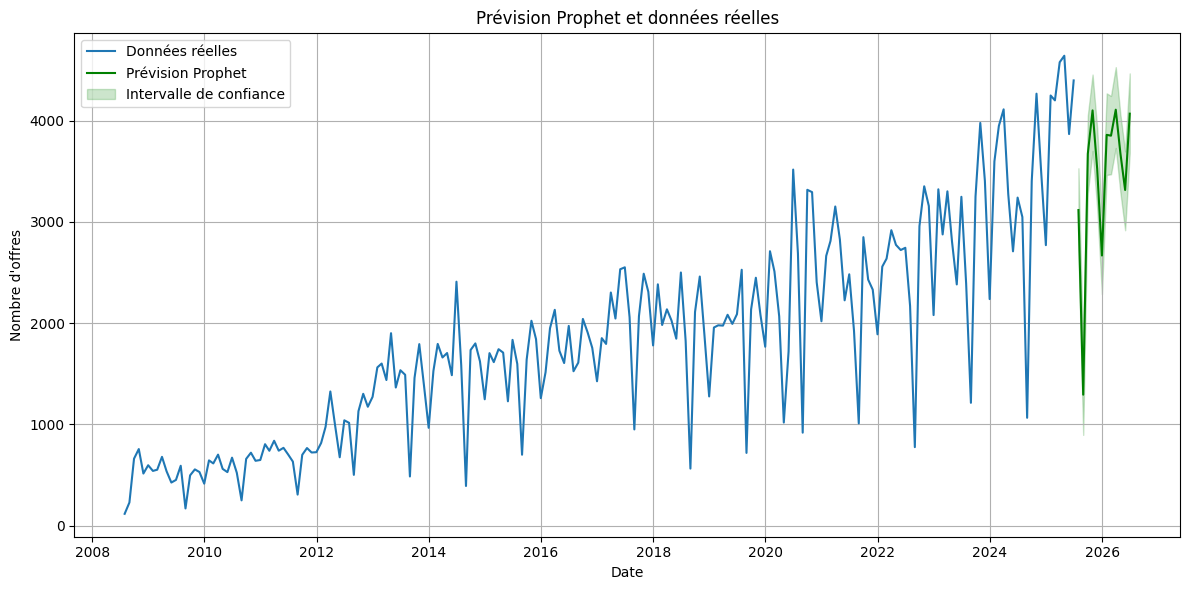

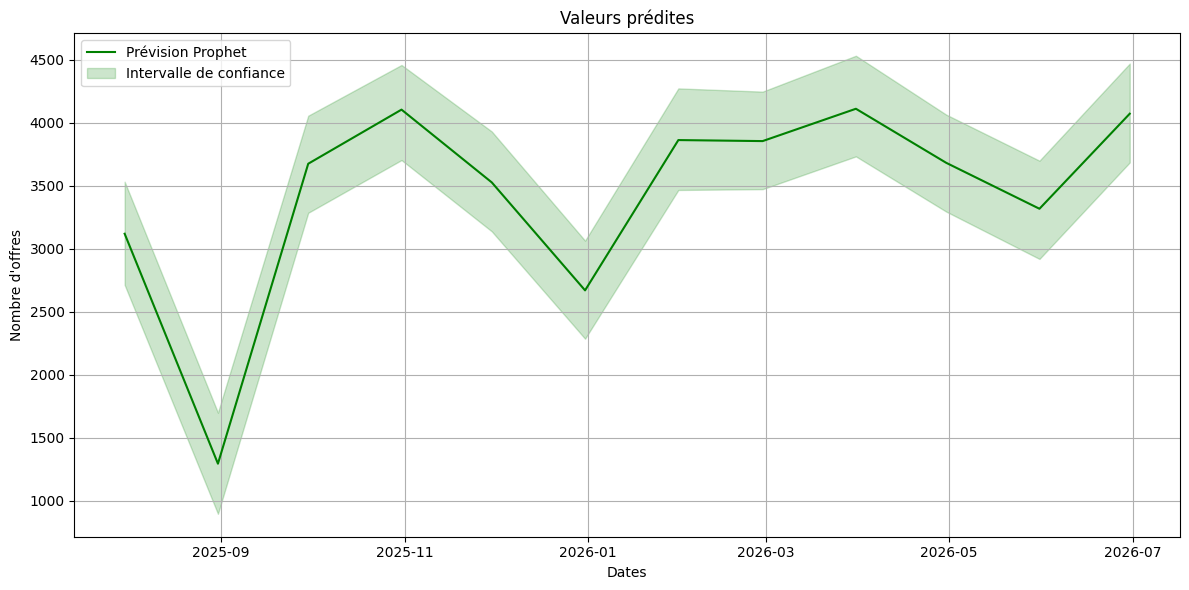

Prévisions pour les 12 mois à venir :
            ds         yhat
204 2025-07-31  3117.959492
205 2025-08-31  1293.538516
206 2025-09-30  3673.470944
207 2025-10-31  4102.774871
208 2025-11-30  3525.271017
209 2025-12-31  2668.736771
210 2026-01-31  3861.224357
211 2026-02-28  3853.093904
212 2026-03-31  4109.617009
213 2026-04-30  3680.879013
214 2026-05-31  3316.216841
215 2026-06-30  4070.386994


In [ ]:
from prophet.plot import plot_plotly

# Étendre les dates futures (12 mois après la dernière date)
future = model_prophet.make_future_dataframe(periods=12, freq='M')

# Générer les prévisions
forecast = model_prophet.predict(future)

# Extraire les prédictions futures uniquement
forecast_future = forecast[forecast['ds'] > df_complete['mois'].max()]

# Tracer la série historique + prévisions
plt.figure(figsize=(12, 6))
plt.plot(df_complete['mois'], df_complete['nb_offres'], label='Données réelles')

# Tracer les prédictions de Prophet
plt.plot(forecast_future['ds'], forecast_future['yhat'], label='Prévision Prophet', color='green')

# Ajouter la zone d’incertitude
plt.fill_between(forecast_future['ds'], forecast_future['yhat_lower'], forecast_future['yhat_upper'], 
                 color='green', alpha=0.2, label='Intervalle de confiance')

plt.title("Prévision Prophet et données réelles")
plt.xlabel("Date")
plt.ylabel("Nombre d'offres")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(forecast_future['ds'], forecast_future['yhat'], label='Prévision Prophet', color='green')
plt.fill_between(forecast_future['ds'], forecast_future['yhat_lower'], forecast_future['yhat_upper'], 
                 color='green', alpha=0.2, label='Intervalle de confiance')
plt.title('Valeurs prédites')
plt.xlabel('Dates')
plt.ylabel('Nombre d\'offres')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 5. Afficher les valeurs prédites
print("Prévisions pour les 12 mois à venir :")
print(forecast_future[['ds', 'yhat']])

# Les résultats du modèle prophet sont plus pessimistes que ceux du modèle ARIMA, mais ils semblent plus réalistes sur la modélisation de l'effet
# de saisonnalité brusque du mois d'août. En effet, les baisses d'activités sont de plus en plus brutales avec le temps, ce que parvient bien à
# capturer prophet.

In [ ]:
from statsmodels.stats.diagnostic import het_arch
stat, pval, _, _ = het_arch(returns)
print(f"P-value du test d'ARCH : {pval}")
if pval < 0.05 :
    print('Il y a hétéroscédasticité de la variance conditionnelle, il faut passer par un modèle ARCH ou GARCH pour la prévoir.')

P-value du test d'ARCH : 0.0001680369498809305
Il y a hétéroscédasticité de la variance conditionnelle, il faut passer par un modèle ARCH ou GARCH pour la prévoir.


Pour compléter : analyse des évolutions de la variance conditionnelle, meilleur modèle et prédictions optimales

In [ ]:
# Copié collé du code de base pour recréer proprement la série temporelle
df['off_date_creation'] = pd.to_datetime(df['off_date_creation'])
ajd = pd.Timestamp.today()
seventeen_years_ago = ajd - pd.DateOffset(years=17)
df_recent = df[df['off_date_creation'] >= seventeen_years_ago].copy()
df_recent['mois'] = df_recent['off_date_creation'].dt.to_period('M').dt.to_timestamp() + pd.offsets.MonthEnd(0)
df_grouped = df_recent.groupby('mois').size().reset_index(name='nb_offres')
full_range = pd.date_range(
    start=df_grouped['mois'].min(),
    end=df_grouped['mois'].max(),
    freq='M'
)
df_full = pd.DataFrame({'mois': full_range})
df_complete = pd.merge(df_full, df_grouped, on='mois', how='left')
df_complete['nb_offres'] = df_complete['nb_offres'].fillna(0).astype(int)
df_complete = df_complete[df_complete['mois'] != df_complete['mois'].max()]

ts = df_complete['nb_offres'].astype(float)
for i in range(param_non_saison[1]) : # On différencie autant de fois que le préconise la sélection automatique du meilleur ARIMA
    ts = ts.diff().dropna()

C:\Users\quent\AppData\Local\Temp\ipykernel_8012\1958138731.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_range = pd.date_range(


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts.dropna())  # .dropna() si la série contient des NaN

# Résultats
print('Statistique ADF :', result[0])
print('p-value :', result[1])
print('Ordre de différenciation :', result[2])
print('Nombre d\'observations :', result[3])
print('Valeurs critiques :')
for key, value in result[4].items():
    print(f'   {key} : {value}')
if result[1] < 0.05 :
    print('La série est bien stationniare, on peut continuer l\'analyse')

Statistique ADF : -5.063482808741927
p-value : 1.6593435216730203e-05
Ordre de différenciation : 13
Nombre d'observations : 189
Valeurs critiques :
   1% : -3.4654311561944873
   5% : -2.8769570530458792
   10% : -2.574988319755886
La série est bien stationniare, on peut continuer l'analyse


C:\Users\quent\AppData\Local\Temp\ipykernel_8012\3680927733.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_range = pd.date_range(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.562e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.562e+05. Parameter
estimation work better when this

mu          6.686778e-01
omega       6.506439e-01
alpha[1]    6.090674e-02
beta[1]     6.163126e-01
beta[2]     1.000000e+00
beta[3]     1.172958e-02
nu          1.038292e-14
Name: pvalues, dtype: float64
mu          3.445824e-01
omega       4.583635e-01
alpha[1]    7.295120e-03
beta[1]     1.000000e+00
beta[2]     2.814301e-08
Name: pvalues, dtype: float64
mu          5.873785e-01
omega       3.649288e-01
alpha[1]    2.440667e-02
beta[1]     3.352612e-22
nu          1.450036e-10
Name: pvalues, dtype: float64
Le modèle GARCH retenu a un comportement asymptotique stationnaire, ce qui pourrait mener à une variance conditionnelle plate à plus ou moins long terme.

=== Meilleur modèle sélectionné ===
GARCH(1, 1) avec AIC = 3144.75
                           Constant Mean - GARCH Model Results                            
Dep. Variable:                          nb_offres   R-squared:                       0.000
Mean Model:                         Constant Mean   Adj. R-squared:              

c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.562e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.562e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn

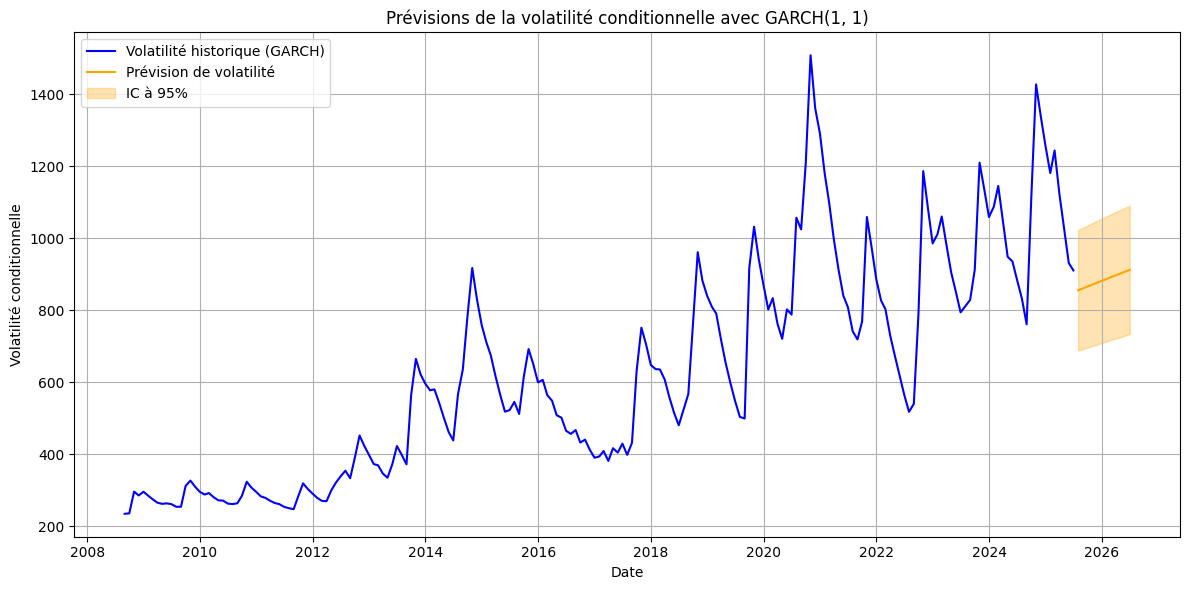

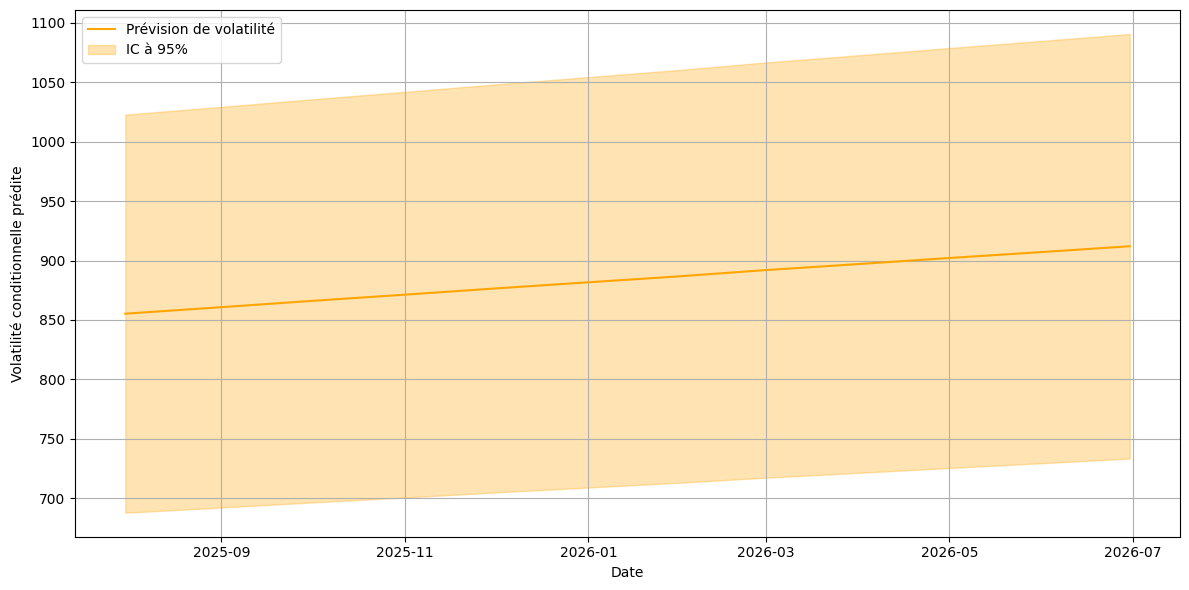

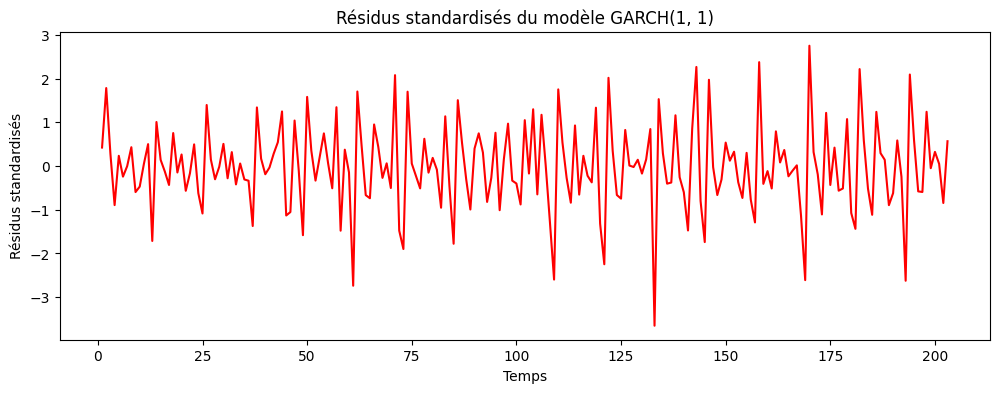

In [ ]:
# Copié collé du code de base pour recréer proprement la série temporelle
df['off_date_creation'] = pd.to_datetime(df['off_date_creation'])
ajd = pd.Timestamp.today()
seventeen_years_ago = ajd - pd.DateOffset(years=17)
df_recent = df[df['off_date_creation'] >= seventeen_years_ago].copy()
df_recent['mois'] = df_recent['off_date_creation'].dt.to_period('M').dt.to_timestamp() + pd.offsets.MonthEnd(0)
df_grouped = df_recent.groupby('mois').size().reset_index(name='nb_offres')
full_range = pd.date_range(
    start=df_grouped['mois'].min(),
    end=df_grouped['mois'].max(),
    freq='M'
)
df_full = pd.DataFrame({'mois': full_range})
df_complete = pd.merge(df_full, df_grouped, on='mois', how='left')
df_complete['nb_offres'] = df_complete['nb_offres'].fillna(0).astype(int)
df_complete = df_complete[df_complete['mois'] != df_complete['mois'].max()]

# Fit du meilleur modèle GARCH : 

ts = df_complete['nb_offres'].astype(float)
for i in range(param_non_saison[1]) : # On différencie autant de fois que le préconise la sélection automatique du meilleur ARIMA
    ts = ts.diff().dropna()

best_aic = np.inf
best_order = None
best_model = None
best_res = None

max_p = 8
max_q = 8

for p in range(1, max_p+1):
    for q in range(1, max_q+1):
        for distrib in ['t','ged','normal']: # On teste trois distributions possibles pour les résidus à chaques fois
            try:
                model = arch_model(ts, vol='Garch', p=p, q=q, dist=distrib)
                res = model.fit(disp='off')
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = (p, q)
                    best_model = model
                    best_res = res
            except Exception as e:
                print(f"GARCH({p},{q}) a échoué : {e}")

pvalues=best_res.pvalues

# Suppose que best_model et best_res sont définis à ce stade
p, q = best_order

# Réduction de q si alpha[q] non significatif
# while len(pvalues) > 5 and q > 1 and pvalues.iloc[-2] > 0.05:
#     q -= 1
#     best_aic = np.inf
#     for distrib in ['t', 'ged', 'normal']:
#         try:
#             model = arch_model(ts, vol='Garch', p=p, q=q, dist=distrib)
#             res = model.fit(disp='off')
#             if res.aic < best_aic:
#                 best_aic = res.aic
#                 best_order = (p, q)
#                 best_model = model
#                 best_res = res
#         except Exception as e:
#             print(f"GARCH({p},{q}) avec {distrib} a échoué : {e}")
#     pvalues = best_res.pvalues

# # Réduction de p si beta[p] non significatif
# while len(pvalues) > 5 and p > 1 and pvalues.iloc[-q-2] > 0.05:
#     p -= 1
#     best_aic = np.inf
#     for distrib in ['t', 'ged', 'normal']:
#         try:
#             model = arch_model(ts, vol='Garch', p=p, q=q, dist=distrib)
#             res = model.fit(disp='off')
#             if res.aic < best_aic:
#                 best_aic = res.aic
#                 best_order = (p, q)
#                 best_model = model
#                 best_res = res
#         except Exception as e:
#             print(f"GARCH({p},{q}) avec {distrib} a échoué : {e}")
#     pvalues = best_res.pvalues

# print(pvalues)
# pvalues_garch = pvalues.iloc[2 + p : 2 + p + q]  # extrait les q p-values qui t'intéressent
# # Vérifie si plus de la moitié sont non significatives (> 0.05)
# if (pvalues_garch > 0.05).sum() / len(pvalues_garch) > 0.5:
#     print("ATTENTION !!! Plus de la moitié des coefficients GARCH (beta) ne sont pas significatifs.")
#     print("Un modèle ARCH pourrait être plus adapté.")

while True:
    while len(pvalues) > 5 and q > 1 and pvalues.iloc[-2] > 0.05:
        q -= 1
        best_aic = np.inf
        for distrib in ['t', 'ged', 'normal']:
            try:
                model = arch_model(ts, vol='Garch', p=p, q=q, dist=distrib)
                res = model.fit(disp='off')
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = (p, q)
                    best_model = model
                    best_res = res
            except Exception as e:
                print(f"GARCH({p},{q}) avec {distrib} a échoué : {e}")
        pvalues = best_res.pvalues

    while len(pvalues) > 5 and p > 1 and pvalues.iloc[-q-2] > 0.05:
        p -= 1
        best_aic = np.inf
        for distrib in ['t', 'ged', 'normal']:
            try:
                model = arch_model(ts, vol='Garch', p=p, q=q, dist=distrib)
                res = model.fit(disp='off')
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = (p, q)
                    best_model = model
                    best_res = res
            except Exception as e:
                print(f"GARCH({p},{q}) avec {distrib} a échoué : {e}")
        pvalues = best_res.pvalues

    print(pvalues)
    pvalues_garch = pvalues.iloc[2 + p : 2 + p + q]  # extrait les q p-values

    if (pvalues_garch > 0.05).sum() / len(pvalues_garch) >= 0.5: # ici si on met >= on obtient GARCH(1,1) et prévision linéaire, si juste >
        # on obtient un GARCH(2,1) et prévisions oscillantes qui convergent vers une variance plate (incohérent) (car dans ce cas p-values du
        # coefficient beta 1 est très élevée, et celui de beta 2 très faible. On simplifie quand même)
        if p > 1:
            p -= 1
            best_aic = np.inf
            for distrib in ['t', 'ged', 'normal']:
                try:
                    model = arch_model(ts, vol='Garch', p=p, q=q, dist=distrib)
                    res = model.fit(disp='off')
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_order = (p, q)
                        best_model = model
                        best_res = res
                except Exception as e:
                    print(f"GARCH({p},{q}) avec {distrib} a échoué : {e}")
            pvalues = best_res.pvalues
        if q > 1 :
            q -= 1
            best_aic = np.inf
            for distrib in ['t', 'ged', 'normal']:
                try:
                    model = arch_model(ts, vol='Garch', p=p, q=q, dist=distrib)
                    res = model.fit(disp='off')
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_order = (p, q)
                        best_model = model
                        best_res = res
                except Exception as e:
                    print(f"GARCH({p},{q}) avec {distrib} a échoué : {e}")
            pvalues = best_res.pvalues
            continue
        else:
            print("Aucun p ni q plus petits possible, arrêt du processus.")
            break
    break  # sortie de la boucle principale si toutes les conditions sont respectées


# Test sur le comportement asymptotique du modèle retenu
alpha_sum = best_res.params.filter(like='alpha').sum()
beta_sum = best_res.params.filter(like='beta').sum()
if (alpha_sum + beta_sum) > 0.95:
    print("Le modèle GARCH retenu a un comportement asymptotique stationnaire, ce qui pourrait mener à une variance conditionnelle plate à plus ou moins long terme.")


print("\n=== Meilleur modèle sélectionné ===")
print(f"GARCH{best_order} avec AIC = {best_aic:.2f}")
print(best_res.summary())

historical_vol = best_res.conditional_volatility

# Prévisions futures (écart-type)
vol_forecast = best_res.forecast(horizon=12)
future_vol = np.sqrt(vol_forecast.variance.values[-1])  # taille 12

# Créer l'axe des temps
last_date = df_complete['mois'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=12, freq='M')

std_err = 0.10 * future_vol  # 10% d'erreur relative. Non formel mais souvent utilisé pour les simulations de séries temp.

conf_upper = future_vol + 1.96 * std_err # 1,96 est la quantile d'ordre 97,5% de la loi normale centrée réduite
conf_lower = future_vol - 1.96 * std_err

# Tracer l'historique + prévision
plt.figure(figsize=(12,6))
plt.plot(df_complete['mois'].iloc[1:], historical_vol, label='Volatilité historique (GARCH)', color='blue')
plt.plot(future_dates, future_vol, label='Prévision de volatilité', color='orange')
plt.fill_between(future_dates, conf_lower, conf_upper, color='orange', alpha=0.3, label='IC à 95%')
plt.title(f"Prévisions de la volatilité conditionnelle avec GARCH{best_order}")
plt.xlabel("Date")
plt.ylabel("Volatilité conditionnelle")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(future_dates, future_vol, label='Prévision de volatilité', color='orange')
plt.fill_between(future_dates, conf_lower, conf_upper, color='orange', alpha=0.3, label='IC à 95%')
plt.xlabel("Date")
plt.ylabel("Volatilité conditionnelle prédite")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Résidus standardisés
plt.figure(figsize=(12,4))
plt.plot(best_res.std_resid, color='red')
plt.title(f"Résidus standardisés du modèle GARCH{best_order}")
plt.xlabel("Temps")
plt.ylabel("Résidus standardisés")
plt.show()

# Interprétation des paramètres : le omega est la variance constante, celle qui ne sera jamais éliminée. Ici, la valeur estimée est non
# significative, le plus probable est que la variance de base soit de 0. Le alpha est l'impact des chocs récents, significatifs, le beta est 
# la persistance de la variance, il est significatif. Ce sont les composantes quon ajoute à un modèle ARCH pour en faire un GARCH. 
# La moyenne du modèle n'est pas significative, on conserve l'hypothèse d'une moyenne nulle.
# Le paramètre nu est 1,3 < 2, ce qui indique que les erreurs ne sont pas gaussiennes, d'où la sélection automatique d'une
# distribution GED (generelized error distribution). Ce sont des lois proches des lois normales qui servent à adapter l'épaisseur des queues,
# autrement dit la proba des valeurs extrêmes.

# Le modèle GARCH prévoit une stabilisation de la variance à court terme

In [ ]:
if adfuller(best_res.std_resid)[1] < 0.05 : 
    print('Les résidus sont bien stationnaires : le modèle GARCH est bien spécifié')

Les résidus sont bien stationnaires : le modèle GARCH est bien spécifié


c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.562e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.562e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn

ARCH(1) : AIC = 3159.79
ARCH(2) : AIC = 3159.16
ARCH(3) : AIC = 3154.62
ARCH(4) : AIC = 3147.91
ARCH(5) : AIC = 3149.91

Meilleur modèle trouvé : ARCH(1)
                      Constant Mean - ARCH Model Results                      
Dep. Variable:              nb_offres   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -1576.89
Distribution:                  Normal   AIC:                           3159.79
Method:            Maximum Likelihood   BIC:                           3169.73
                                        No. Observations:                  203
Date:                Fri, Jul 25 2025   Df Residuals:                      202
Time:                        12:58:03   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% 

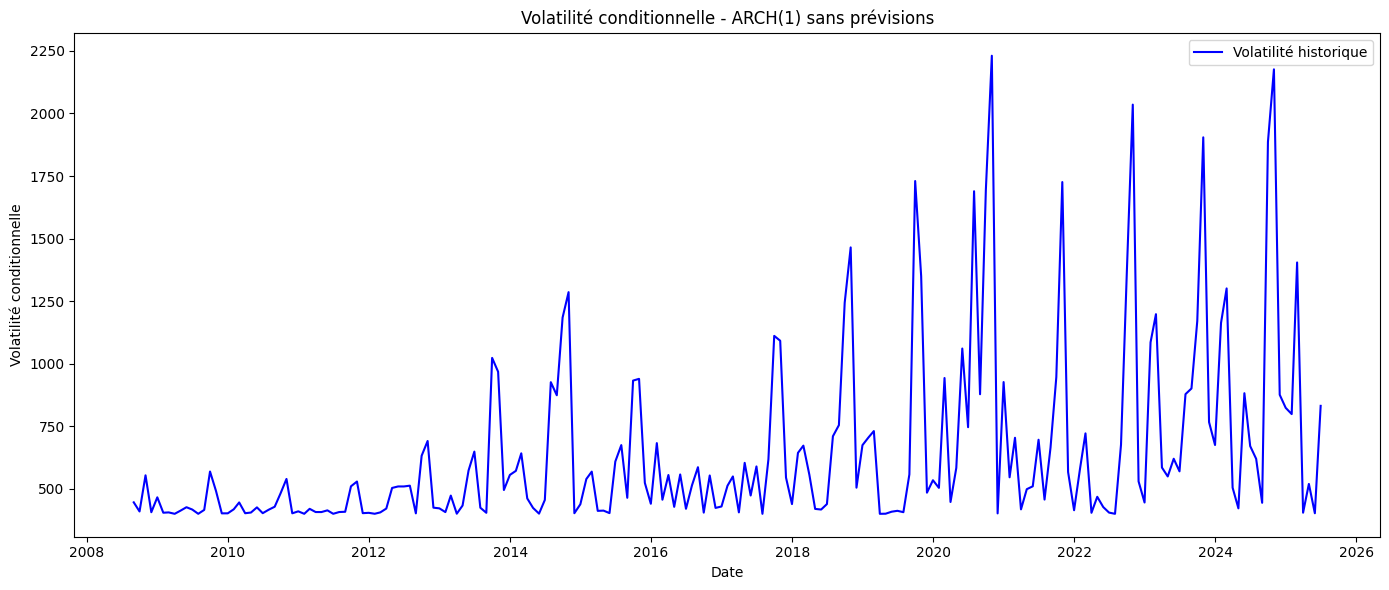

In [ ]:
from arch import arch_model

# Préparation des données
ts = df_complete['nb_offres'].astype(float)
for i in range(param_non_saison[1]) : # On différencie autant de fois que le préconise la sélection automatique du meilleur ARIMA
    ts = ts.diff().dropna()

# Recherche du meilleur modèle ARCH(p)
best_aic = np.inf
best_order = None
best_model = None
best_res = None
max_p = 5 

for p in range(1, max_p + 1):
    try:
        model = arch_model(ts, vol='ARCH', p=p, q=0, dist='normal')
        res = model.fit(disp='off')
        print(f"ARCH({p}) : AIC = {res.aic:.2f}")
        if res.aic < best_aic:
            best_aic = res.aic
            best_order = p
            best_model = model
            best_res = res
    except Exception as e:
        print(f"ARCH({p}) échec : {e}")

pvalues = best_res.pvalues
while pvalues[-1] > 0.05 : 
    if len(pvalues) > 3 :
        best_order = best_order - 1
        best_model = arch_model(ts, vol='ARCH', p=best_order, dist='normal')
        best_res = best_model.fit(disp='off')
        pvalues=pvalues[:-1]
    else : 
        print('Aucun modèle ARCH ne présente d\'alpha significatif, il faudrait pousser l\'analyse plus loin.')

# Résultats
print(f"\nMeilleur modèle trouvé : ARCH({best_order})")
print(best_res.summary())

# 1. Volatilité conditionnelle historique
historical_vol = best_res.conditional_volatility
historical_dates = df_complete['mois'].iloc[-len(historical_vol):]

# 2. Prévision de la variance conditionnelle sur les 12 prochains mois
horizon = 12
forecast_res = best_res.forecast(horizon=horizon)

# 3. Extraire toutes les prévisions (dernière observation -> horizon)
future_cond_var = forecast_res.variance.values[-1, :]
future_cond_vol = np.sqrt(future_cond_var)
print(future_cond_var)
print(future_cond_vol)

# 4. Générer les dates futures
future_dates = pd.date_range(start=historical_dates.iloc[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq='M')

# 5. Calcul de l'IC 95% (approximatif)
upper_bound = future_cond_vol + 1.96 * future_cond_vol
lower_bound = np.maximum(future_cond_vol - 1.96 * future_cond_vol, 0)  # pour éviter < 0

# 6. Affichage
plt.figure(figsize=(14, 6))
plt.plot(historical_dates, historical_vol, label="Volatilité historique", color='blue')
# plt.plot(future_dates, future_cond_vol, label="Prévision de volatilité", color='orange')
# plt.fill_between(future_dates, lower_bound, upper_bound, color='orange', alpha=0.3, label="IC 95% (approx)")

plt.title(f"Volatilité conditionnelle - ARCH({best_order}) sans prévisions")
plt.xlabel("Date")
plt.ylabel("Volatilité conditionnelle")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show() # Inutile en fait, les modèles ARCH ne modélisent la variance qu'à partir des chocs passés, ils ne modélisent pas une persistance de la
# volatitlité elle-même. GARCH est plus adapté ici car la variance conditionnelle est croissante au cours du temps

In [ ]:
# Copié collé du code de base pour recréer proprement la série temporelle
df['off_date_creation'] = pd.to_datetime(df['off_date_creation'])
ajd = pd.Timestamp.today()
seventeen_years_ago = ajd - pd.DateOffset(years=17)
df_recent = df[df['off_date_creation'] >= seventeen_years_ago].copy()
df_recent['mois'] = df_recent['off_date_creation'].dt.to_period('M').dt.to_timestamp() + pd.offsets.MonthEnd(0)
df_grouped = df_recent.groupby('mois').size().reset_index(name='nb_offres')
full_range = pd.date_range(
    start=df_grouped['mois'].min(),
    end=df_grouped['mois'].max(),
    freq='M'
)
df_full = pd.DataFrame({'mois': full_range})
df_complete = pd.merge(df_full, df_grouped, on='mois', how='left')
df_complete['nb_offres'] = df_complete['nb_offres'].fillna(0).astype(int)
df_complete = df_complete[df_complete['mois'] != df_complete['mois'].max()]

ts = df_complete['nb_offres'].astype(float)

C:\Users\quent\AppData\Local\Temp\ipykernel_8012\1247595713.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_range = pd.date_range(


In [ ]:
from statsmodels.tsa.stattools import adfuller
ordre_differenciation = 0
while adfuller(ts.dropna())[1] > 0.05 :  # .dropna() si la série contient des NaN
    ts = ts.diff().dropna()
    ordre_differenciation += 1
    result = adfuller(ts.dropna())
# Résultats
print('Statistique ADF :', result[0])
print('p-value :', result[1])
print(' :', result[2])
print('Nombre de retards :', result[3])
print('Valeurs critiques :')
for key, value in result[4].items():
    print(f'   {key} : {value}')
if result[1] < 0.05 :
    print('La série est bien stationniare, on peut continuer l\'analyse. Ordre de différenciation : ', ordre_differenciation)

# On croise les résultats avec ceux du test KPSS pour être sûr
from statsmodels.tsa.stattools import kpss

statistic, p_value, lags, critical_values = kpss(ts, regression='c')
while kpss(ts, regression='c')[1] < 0.05 :
    ts = ts.diff().dropna()
    ordre_differenciation += 1
    statistic, p_value, lags, critical_values = kpss(ts, regression='c')  # 'c' pour constante (stationnarité autour d'une moyenne)

print('Statistique KPSS:', statistic)
print('p-value:', p_value)
print('Nombre de retards:', lags)
print('Valeurs critiques:', critical_values)


Statistique ADF : -5.063482808741927
p-value : 1.6593435216730203e-05
 : 13
Nombre de retards : 189
Valeurs critiques :
   1% : -3.4654311561944873
   5% : -2.8769570530458792
   10% : -2.574988319755886
La série est bien stationniare, on peut continuer l'analyse. Ordre de différenciation :  1
Statistique KPSS: 0.1225325174157282
p-value: 0.1
Nombre de retards: 26
Valeurs critiques: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\quent\AppData\Local\Temp\ipykernel_8012\2334735456.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(ts, regression='c')
C:\Users\quent\AppData\Local\Temp\ipykernel_8012\2334735456.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  while kpss(ts, regression='c')[1] < 0.05 :


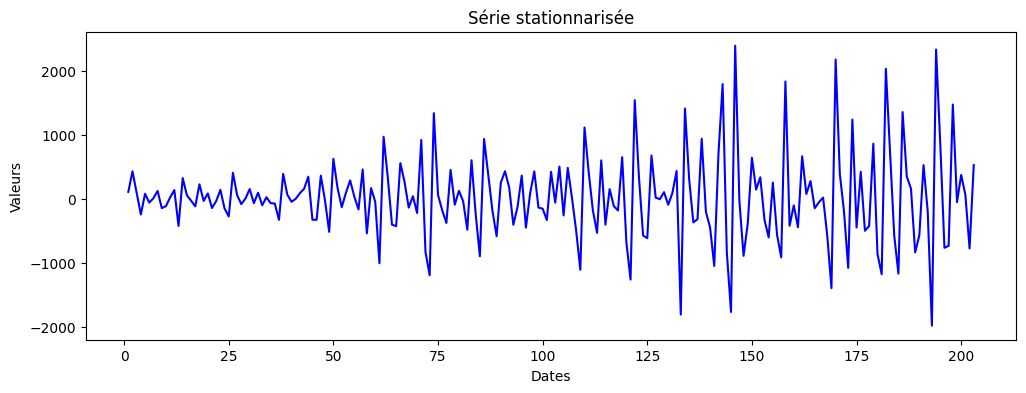

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(ts, color='blue')
plt.title('Série stationnarisée')
plt.xlabel('Dates')
plt.ylabel('Valeurs')
plt.plot()
plt.show()

In [ ]:
import pandas as pd

# Si ts est un DataFrame à une colonne, convertis en Series
if isinstance(ts, pd.DataFrame):
    ts = ts.iloc[:,0]

# Vérifie que l'index est datetime
if not isinstance(ts.index, pd.DatetimeIndex):
    ts.index = pd.to_datetime(ts.index)


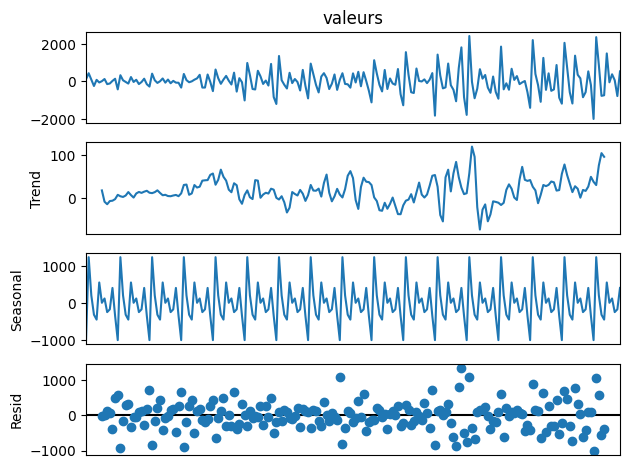

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# suppose ts est un pandas.Series avec un index datetime mensuel
result = seasonal_decompose(ts, model='additive', period=12)  # période 12 pour données mensuelles avec saisonnalité annuelle

result.plot()
plt.show() # Sur le graphique, la saisonnalité est clairement visible

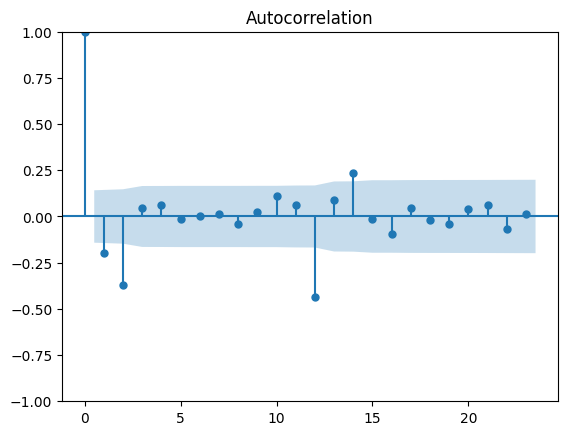

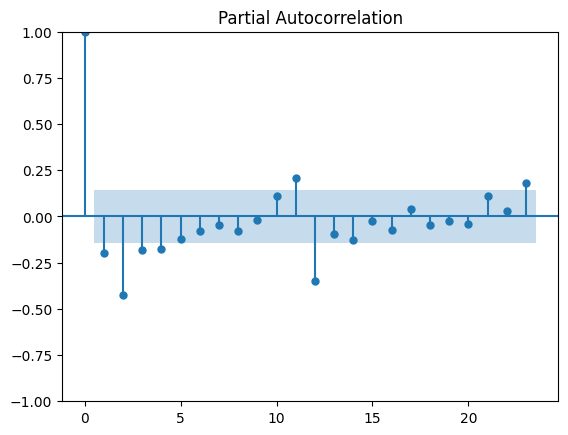

In [ ]:
ts_diff_saison = ts.diff(12).dropna()
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_diff_saison)
plot_pacf(ts_diff_saison)
plt.show() # On prend q=2 et p=4 comme maximum

c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1516.81
Distribution:                  Normal   AIC:                           3041.63
Method:            Maximum Likelihood   BIC:                           3054.88
                                        No. Observations:                  203
Date:                Fri, Jul 25 2025   Df Residuals:                      202
Time:                        14:09:58   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu           -18.0930     27.113     -0.667      0.505 [-71.234, 35.04

c:\Users\quent\OneDrive\Documents\Stage Ipso\Codes python\.venv\lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.497e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


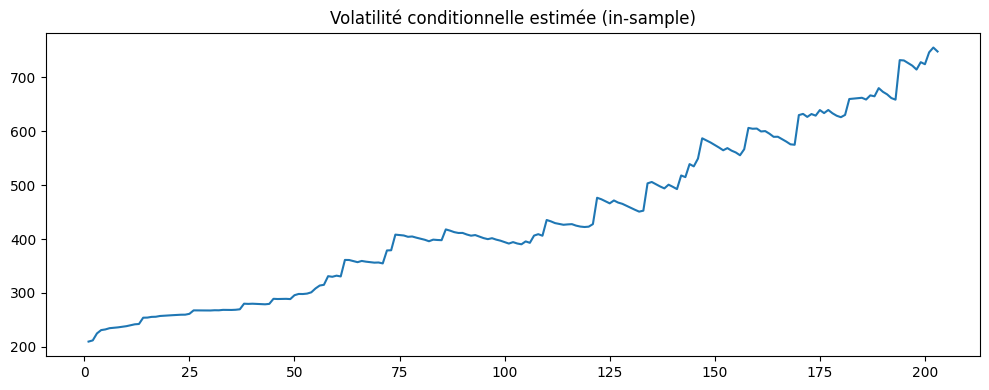

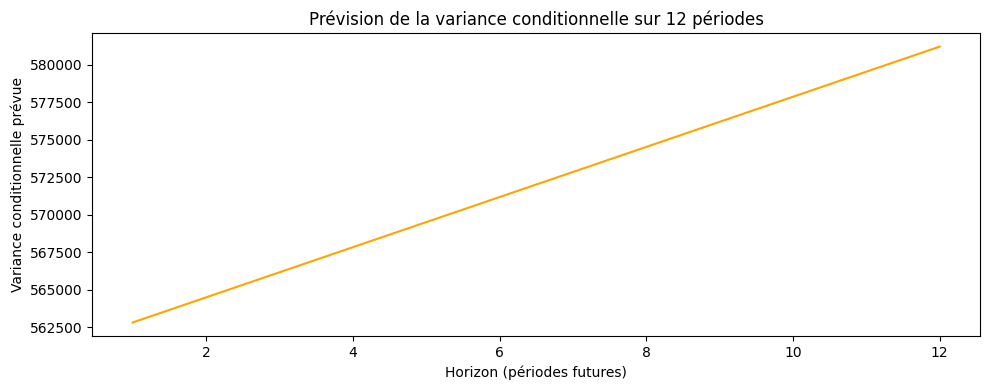

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# Estimer ARMA(4,2) sur ta série ts (stationnaire)
arma_model = ARIMA(ts, order=(2, 0, 2)).fit()

# Résidus ARMA
residus = arma_model.resid

# Ajuster GARCH(1,1) sur ces résidus
garch_model = arch_model(residus, vol='Garch', p=1, q=1, dist='normal')
garch_res = garch_model.fit(disp='off')

# Résumé
print(garch_res.summary())

# Graphique de la volatilité conditionnelle estimée
plt.figure(figsize=(10, 4))
plt.plot(garch_res.conditional_volatility)
plt.title('Volatilité conditionnelle estimée (in-sample)')
plt.tight_layout()
plt.show()

# Prévision de la variance conditionnelle (volatilité au carré)
horizon = 12  # nombre de périodes à prévoir
forecast = garch_res.forecast(horizon=horizon)
variance_forecast = forecast.variance.values[-1, :]  # dernière ligne, horizon h

# Affichage des prévisions
plt.figure(figsize=(10, 4))
plt.plot(range(1, horizon + 1), variance_forecast, color='orange')
plt.title(f'Prévision de la variance conditionnelle sur {horizon} périodes')
plt.xlabel('Horizon (périodes futures)')
plt.ylabel('Variance conditionnelle prévue')
plt.grid(False)
plt.tight_layout()
plt.show()
# Comme alpha + beta = 1, on a une persistance extrême de la variance historique. La p-value très élevée du test de nullité du coefficient alphs
# indique une quasi inutilité des chocs passés pour prédire la variance future, d'où la prévision linéaire. 